In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [4]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset 20 Newsgroups (on prend un sous-échantillon pour la rapidité)
data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
X_text = data.data[:2000]
y = data.target[:2000]

# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(max_features=100)
X = vectorizer.fit_transform(X_text).toarray()
feature_names = vectorizer.get_feature_names_out()

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=100,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Explication locale (feature, poids):
[('use', 0.14826037168797168), ('for', 0.0819103938682613), ('his', -0.0482290134427759), ('will', 0.04362034197369444), ('there', 0.042833333333333334), ('were', -0.03363581934592638), ('he', -0.033365174056071104), ('can', 0.022904204054503163), ('these', -0.02179487179487182), ('with', -0.021487142937650295), ('people', 0.018815775357613522), ('been', 0.015833333333333335), ('see', 0.012724680325486798), ('was', -0.011995556660325103), ('you', -0.011058013658820124), ('145', 0.009570870721169845), ('all', -0.006820597487570509), ('as', -0.006679039823794489), ('and', 0.005528482337407527), ('that', -0.005108009828203829), ('max', 0.0050000000000000044), ('my', 0.003750006543847934), ('the', -0.002923840039086344), ('not', -0.0026706808921755365), ('to', 0.0), ('on', 0.0), ('it', 0.0), ('but', 0.0), ('they', 0.0), ('be', 0.0), ('what', 0.0), ('if', 0.0), ('out', 0.0),

In [5]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=10
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('use', 0.003968698419601668), ('his', -0.0026263827880790604), ('that', -0.002579785781271487), ('were', -0.002422812431296079), ('people', -0.0022101015692816053), ('as', -0.0017066170250232616), ('and', 0.001142820047613939), ('the', -0.0010761673434566618), ('on', 0.0010699773775480067), ('to', 0.0006066924577636095)]


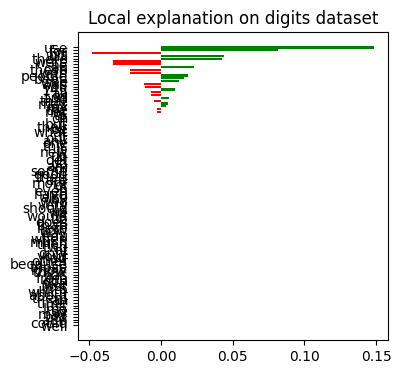

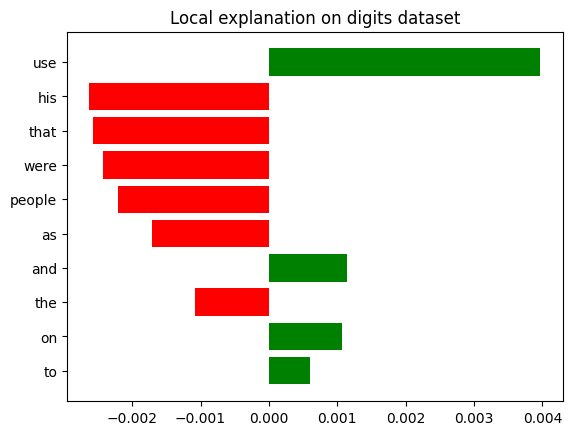

In [6]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on digits dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on digits dataset")
plt.show()